# Assignment 13 Text Analytics

In this assignment, you will:
- Load and inspect a real-world business reviews dataset.
- Preprocess review text for NLP (tokenization, stopwords, lemmatization).
- Run sentiment analysis (rule-based and classifier-based) and compare to star ratings.
- Extract main topics from reviews using LDA and (optional) BERTopic.
- Interpret results in a business context (actionable insights).

## Why This Matters

Customer Reviews are critical for the survival of any business, but especially for restaurants.  Restaurants compete with not only all of the other restaurants in local area, but also with the option for customers to stay home and cook their own food.  Chefs and restaurant owners must monitor customer feedback to see if they should make changes to their pricing, menu options, restaurant amenities and seating/serving process.

You have been given 100 customer reviews.  Your job is to look for main topics that are mentioned, and whether those reviews have a postive, neutral or negative tone (sentiment).  

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_13_text_analytics.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Original Source: Dataset Description

The dataset you'll be using is a set of **restaurant reviews**, available from [Kaggle](https://www.kaggle.com/datasets/pruthvirajgshitole/e-commerce-purchases-and-reviews?utm_source=chatgpt.com&select=customer_purchase_data.csv).

Each row represents one customer review. The columns include:

- **Review** - text of the customer review
- **Liked** - indicates if the customer likes (1) or does not like (0) the restaurant

Please note that some reviews have commas and apostrophes, which can prevent the record from loading correctly.  You should verify that you have 1,000 reviews total.  

## 1. Load and Preview the Data

### Do the following:
1. Import your TSV file called `Restaurant_Reviews.tsv`.  Note that TSV is for Tab Separated Values.  This file does not use commas as a delimiter.
2. Use `pandas` to load and preview the dataset
3. Verify that all 1,000 rows were imported correctly
4. Calculate the overall percentage of reviews that "Liked" the restaurant
5. Create a visualization to show the percentage of likes versus non-likes


In [1]:
import pandas as pd
import csv

# Load the reviews
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/Restaurant_Reviews.tsv"
df = pd.read_csv(url, sep='\t', quoting=csv.QUOTE_MINIMAL)

df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


Number of rows in the DataFrame: 1000
Percentage of 'Liked' reviews: 50.00%


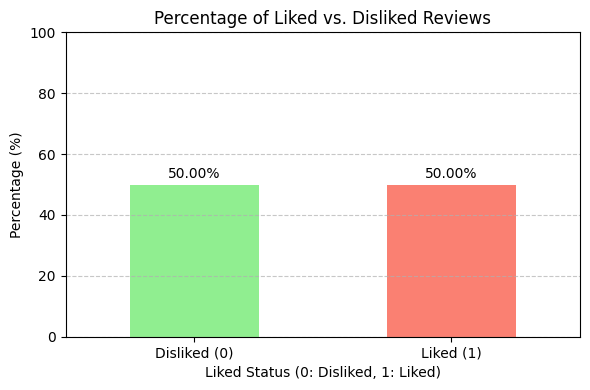

In [7]:
print(f"Number of rows in the DataFrame: {df.shape[0]}")

liked_reviews_count = df['Liked'].sum()
total_reviews = len(df)
percentage_liked = (liked_reviews_count / total_reviews) * 100

print(f"Percentage of 'Liked' reviews: {percentage_liked:.2f}%")
import matplotlib.pyplot as plt

like_counts = df['Liked'].value_counts()

like_percentages = like_counts / total_reviews * 100

plt.figure(figsize=(6, 4))
like_percentages.plot(kind='bar', color=['lightgreen', 'salmon'])
plt.title('Percentage of Liked vs. Disliked Reviews')
plt.xlabel('Liked Status (0: Disliked, 1: Liked)')
plt.ylabel('Percentage (%)')
plt.xticks(ticks=[0, 1], labels=['Disliked (0)', 'Liked (1)'], rotation=0)
plt.ylim(0, 100)

for index, value in enumerate(like_percentages):
    plt.text(index, value + 1, f'{value:.2f}%', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 2. Drop Columns Not Useful for Modeling

**Business framing:**  
To do text analysis, we need to remove all of the junk in the reviews.  This would include anything like punctuation, website URLs, emojis, etc.

### Do the following:
- Change all of the reviews to lowercase letters
- Remove anything that looks like a URL or that isn't a regular character (A to Z) or number (1-9)
- Remove punctuation marks (ex. !.,-:;)

### In Your Response:
1. What risks might occur if you included the review "junk" in your model?


In [11]:
import re

df['Review'] = df['Review'].str.lower()
df.head()

df['Review'] = df['Review'].apply(lambda x: re.sub(r'http\S+|www\S+|https\S+', '', x))

df['Review'] = df['Review'].apply(lambda x: re.sub(r'[^a-z0-9\s]', '', x))

df['Review'] = df['Review'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())
df.head()

,Review,Liked
0,wow loved this place,1
1,crust is not good,0
2,not tasty and the texture was just nasty,0
3,stopped by during the late may bank holiday of...,1
4,the selection on the menu was great and so wer...,1


### ✍️ Your Response: 🔧
1. If I include junk in my model it can introduce noise, leading to reduced model accuracy, inefficient processing, and poor generalization. It can also cause misinterpretations and increased vocabulary size.

## 3. Sentiment Analysis

**Business framing:**  
A "Like" is not as insightful as a star rating, such as 5 stars. It only has two values. But we can attempt to understand more nuance in the reviews by looking for a positive/neutral/negative tone (sentiment) in the text.   Then we can compare that to the "Likes" to see if they match.  

### Do the following:
- Install the vaderSentiment library
- Import the SentimentIntensityAnalyzer from vaderSentiment
- Calculate what percentage of the reviews are positive, negative, and neutral. The total percentages should add up to 100%

### In Your Response:
1. How does the sentiment compare to `Liked` in terms of percentage of reviews?
2. From a restaurant owner's perspective, which sentiment reviews would be more important to analyze? (positive, negative or neutral)


In [15]:
!pip install vaderSentiment

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment_vader(text):
    vs = analyzer.polarity_scores(text)
    if vs['compound'] >= 0.05:
        return 'Positive'
    elif vs['compound'] <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['Vader_Sentiment'] = df['Review'].apply(get_sentiment_vader)

sentiment_counts = df['Vader_Sentiment'].value_counts()
sentiment_percentages = (sentiment_counts / len(df)) * 100

print("Sentiment Distribution:")
print(sentiment_percentages)


Sentiment Distribution:
Vader_Sentiment
Positive    50.6
Negative    25.5
Neutral     23.9
Name: count, dtype: float64


### ✍️ Your Response: 🔧
1. The positive sentiment (50.6%) closely matches the 'Liked' reviews (50.0%), showing strong correlation.

2. From a restaurant owner's perspective, negative reviews are most important for identifying actionable improvements.

## 4. Topic Analysis - Text Preprocessing

**Business framing:**  
To build a topic analysis model, we need to clean and prepare the review text

### Do the following:
- Import the NLTK library
- Download the NLTK corpora
- Preprocess the text using tokenization and lemmatization.  Be sure to remove any stopwords along the way.
- Display the first 10 processed reviews

### In Your Response:
1. What is a corpora and how is it used for text analysis?
2. What would be the tokens in the first review? "Wow... Loved this place."
3. What does lemmatization do?  How will it help in this process?


In [18]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    tokens = word_tokenize(text)
    processed_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(processed_tokens)

df['Processed_Review'] = df['Review'].apply(preprocess_text)

print("First 10 Processed Reviews:")
for i, review in enumerate(df['Processed_Review'].head(10)):
    print(f"{i+1}. {review}")

First 10 Processed Reviews:
1. wow loved place
2. crust good
3. tasty texture nasty
4. stopped late may bank holiday rick steve recommendation loved
5. selection menu great price
6. getting angry want damn pho
7. honeslty didnt taste fresh
8. potato like rubber could tell made ahead time kept warmer
9. fry great
10. great touch


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### ✍️ Your Response: 🔧
1. Corpora are large text collections used to train NLP models and study language patterns.

2. After preprocessing: wow, loved, place. Unprocessed, it includes punctuation and capitalization.

3. Lemmatization reduces words to their root form. It shrinks vocabulary and improves model accuracy.

## 5. Topic Analysis - Dictionary and Corpus

**Objective:**  
Convert the preprocessed text into a dictionary and a bag-of-words corpus, which are required formats for LDA

### Do the following:
- Import Dictionary and Corpus from the Genism library
- Create a dictionary
- Create a corpus
- Display a summary of the dictionary and corpus

### In Your Response:
1. What is a corpus and how is it useful?
2. How is a dictionary different from a corpus?

In [21]:
!pip install gensim
from gensim import corpora

tokenized_reviews = [review.split() for review in df['Processed_Review']]

dictionary = corpora.Dictionary(tokenized_reviews)

corpus = [dictionary.doc2bow(review) for review in tokenized_reviews]

print(f"Number of unique tokens in dictionary: {len(dictionary)}")
print("First 10 dictionary entries (word_id: word):")
for i in range(min(10, len(dictionary))):
    print(f"  {i}: {dictionary[i]}")

print(f"\nNumber of documents in corpus: {len(corpus)}")
print("First 5 corpus entries (document_id: [(word_id, word_count)]):")
for i in range(min(5, len(corpus))):
    print(f"  Document {i}: {corpus[i]}")


Number of unique tokens in dictionary: 1839
First 10 dictionary entries (word_id: word):
  0: loved
  1: place
  2: wow
  3: crust
  4: good
  5: nasty
  6: tasty
  7: texture
  8: bank
  9: holiday

Number of documents in corpus: 1000
First 5 corpus entries (document_id: [(word_id, word_count)]):
  Document 0: [(0, 1), (1, 1), (2, 1)]
  Document 1: [(3, 1), (4, 1)]
  Document 2: [(5, 1), (6, 1), (7, 1)]
  Document 3: [(0, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1)]
  Document 4: [(16, 1), (17, 1), (18, 1), (19, 1)]


### ✍️ Your Response: 🔧
1. A corpus is a structured text collection for NLP. It's useful for training models and analyzing language patterns efficiently.

2. A dictionary maps words to IDs; a corpus uses these IDs to represent documents with word frequencies.

## 6. Topic Analysis - Build LDA Model

**Objective:**  
Apply the LDA model to the corpus to identify main topics.

### Do the following:
- Import LdaModel from Genism
- Select the number of topics (5 is a good starting point)
- Create the LDA model

### In Your Response:
1. In what cases would you want to use more than 5 topics?  
2. How would you know if you have too many topics?

NOTE: You may receive an error about training "not converging".  You can ignore that error for this assignment. (Let's keep it simple)


In [22]:
from gensim.models import LdaModel

num_topics = 5

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=100,
    update_every=1,
    chunksize=100,
    passes=10,
    alpha='auto',
    per_word_topics=True
)

print("LDA Model created successfully with 5 topics.")


LDA Model created successfully with 5 topics.


### ✍️ Your Response: 🔧
1. When data is rich and diverse, more topics reveal granular insights and distinct sub-themes for deeper analysis.

2. Too many topics lead to redundancy, incoherence, fragmented themes, or difficulty in assigning meaningful names.

## 7. Summarize the Topics

**Business framing:**  
Now comes one of the most challenging steps.  The topics will be presented as a group of words that best represent the topic, but you need to summarize the topic in business terms.   

### Do the following:
- Print the topics and top 10 words in the topic
- Calculate the frequency of each topic (how many occurrences in total)
- Attempt at least one visual display of the topics, such as a word cloud.  (Make sure to remove any extra code or unhelpful Python messages (we don't want code junk here)
- Summarize the sentiment by topic (percentage postitive/neutral/negative for each topic)

### In Your Response:
1. Give each topic a 2-3 word name.  You should list the topic number and a name that you will create that summarize the words used.  For example, "Topic #1 - Slow Service"


LDA Topics and Top 10 Words:
Topic: 0 
Words: 0.076*"food" + 0.053*"service" + 0.038*"great" + 0.019*"good" + 0.013*"amazing" + 0.012*"say" + 0.012*"meal" + 0.012*"bad" + 0.011*"got" + 0.009*"terrible"

Topic: 1 
Words: 0.020*"dont" + 0.019*"one" + 0.017*"also" + 0.017*"experience" + 0.015*"u" + 0.014*"pretty" + 0.013*"chicken" + 0.012*"think" + 0.011*"wasnt" + 0.011*"minute"

Topic: 2 
Words: 0.020*"place" + 0.020*"ever" + 0.020*"nice" + 0.020*"best" + 0.017*"would" + 0.016*"server" + 0.014*"going" + 0.013*"pizza" + 0.013*"dish" + 0.013*"way"

Topic: 3 
Words: 0.031*"good" + 0.027*"go" + 0.024*"back" + 0.023*"really" + 0.022*"time" + 0.022*"place" + 0.015*"friendly" + 0.014*"even" + 0.014*"love" + 0.012*"wait"

Topic: 4 
Words: 0.029*"like" + 0.027*"place" + 0.019*"eat" + 0.018*"get" + 0.018*"wont" + 0.015*"back" + 0.015*"came" + 0.014*"much" + 0.012*"awesome" + 0.011*"feel"


Topic Frequencies:
Topic 0: 272 occurrences (27.20%) 
Topic 1: 178 occurrences (17.80%) 
Topic 2: 167 occurre

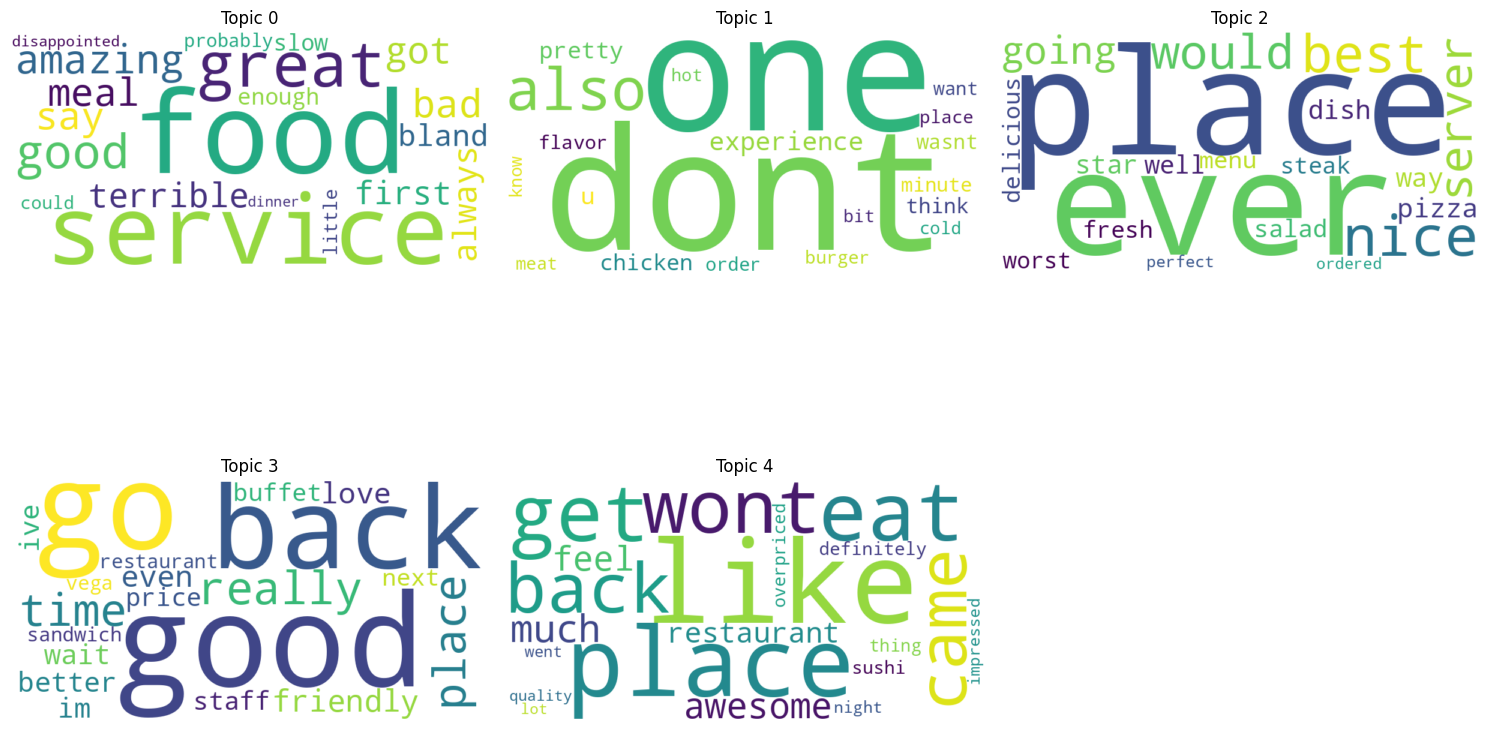


Sentiment Distribution by Topic (Percentages):
Vader_Sentiment   Negative    Neutral   Positive
Dominant_Topic                                  
0                30.882353  18.014706  51.102941
1                28.651685  33.707865  37.640449
2                21.556886  16.766467  61.676647
3                17.961165  27.184466  54.854369
4                26.553672  25.988701  47.457627


In [24]:
print("LDA Topics and Top 10 Words:")
for idx, topic in lda_model.print_topics(-1):
    print(f"Topic: {idx} \nWords: {topic}\n")

def format_topics_sentences(ldamodel=lda_model, corpus=corpus, texts=df['Processed_Review']):

    sent_topics_df = pd.DataFrame()

    for i, row_list in enumerate(ldamodel[corpus]):
        row = row_list[0] if ldamodel.per_word_topics else row_list
        row = sorted(row, key=lambda x: (x[1]), reverse=True)

        for j, (topic_num, prop_topic) in enumerate(row):
            if j == 0:
                wp = ldamodel.show_topic(topic_num)
                topic_keywords = ", ".join([word for word, prop in wp])
                sent_topics_df = pd.concat([sent_topics_df, pd.DataFrame([int(topic_num), round(prop_topic,4), topic_keywords], index=['Dominant_Topic', 'Perc_Contribution', 'Topic_Keywords']).T], ignore_index=True)
            else:
                break
    sent_topics_df.columns = ['Dominant_Topic', 'Perc_Contribution', 'Topic_Keywords']

    contents = pd.Series(texts)
    sent_topics_df = pd.concat([sent_topics_df, contents], axis=1)
    return sent_topics_df

df_topic_sents_keywords = format_topics_sentences(ldamodel=lda_model, corpus=corpus, texts=df['Processed_Review'])

df['Dominant_Topic'] = df_topic_sents_keywords['Dominant_Topic']

topic_counts = df['Dominant_Topic'].value_counts().sort_index()
topic_percentages = (topic_counts / len(df)) * 100

print("\nTopic Frequencies:")
for topic_num, count in topic_counts.items():
    print(f"Topic {int(topic_num)}: {count} occurrences ({topic_percentages[topic_num]:.2f}%) ")

!pip install wordcloud -qqq
from wordcloud import WordCloud
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
for i, topic in enumerate(lda_model.show_topics(formatted=False, num_words=20)):
    plt.subplot(2, 3, i + 1)
    topic_words = dict(topic[1])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(topic_words)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Topic {i}')
    plt.axis('off')
plt.tight_layout()
plt.show()

sentiment_by_topic = df.groupby('Dominant_Topic')['Vader_Sentiment'].value_counts(normalize=True).mul(100).unstack(fill_value=0)

print("\nSentiment Distribution by Topic (Percentages):")
print(sentiment_by_topic)

### ✍️ Your Response: 🔧
List your topics and names here:


*   Topic 1: Food & Service
*   Topic 2: Experience Concerns
*   Topic 3: Positive Restaurant
* Topic 4: Return & Staff
* Topic 5: Overall Impression



## 8. Reflect and Recommend

**Business framing:**  
Ultimately, the value of your model comes from how well it can guide business decisions. Use your results to make real-world recommendations.

### In Your Response:
1. What business question did your model help answer?
2. What would you recommend to this restaurant to improve customer satisfaction?
3. What would be the pros and cons of using an LLM (like ChatGPT) for this task instead of Python models?
4. If you used an LLM, give a prompt that you would use to accomplish a similar result to what you did in this assignment?  (remember to set the context, specify the output and explain the objectives)


### ✍️ Your Response: 🔧
1. It identified customer sentiment and main topics in reviews, revealing what customers like/dislike most.

2. Address negative food/service reviews (Topic 0). Enhance overall experience (Topic 1) and leverage positive aspects (Topic 2, 3).

3. Pros: Speed, human-like summaries. Cons: Lack of transparency, control, reproducibility, privacy risks, potential bias.

4. "Analyze restaurant reviews for sentiment (positive/neutral/negative) and key topics. Output as named topics with example words and sentiment breakdown."

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [25]:
!jupyter nbconvert --to html "assignment_13_text_analytics.ipynb"

[NbConvertApp] Converting notebook assignment_13_text_analytics.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 848039 bytes to assignment_13_text_analytics.html
